# 정규성을 만족하지 않는 반복측정인 경우 -> 프리드만

In [13]:

# Taste 데이터 (66개: 22명 x 3종류 와인)
taste_values = [
    5.40, 5.50, 5.55,  5.85, 5.70, 5.75,  5.20, 5.60, 5.50,
    5.55, 5.50, 5.40,  5.90, 5.85, 5.70,  5.45, 5.55, 5.60,
    5.40, 5.40, 5.35,  5.45, 5.50, 5.35,  5.25, 5.15, 5.00,
    5.85, 5.80, 5.70,  5.25, 5.20, 5.10,  5.65, 5.55, 5.45,
    5.60, 5.35, 5.45,  5.05, 5.00, 4.95,  5.50, 5.50, 5.40,
    5.45, 5.55, 5.50,  5.55, 5.55, 5.35,  5.45, 5.50, 5.55,
    5.50, 5.45, 5.25,  5.65, 5.60, 5.40,  5.70, 5.65, 5.55,
    6.30, 6.30, 6.25
]

# 와인 라벨
wines = ['Wine A', 'Wine B', 'Wine C'] * 22
# 시음자 ID
tasters = sum([[i]*3 for i in range(1, 23)], [])  # [1,1,1, 2,2,2, ..., 22,22,22]

# 데이터프레임 구성
df = pd.DataFrame({
    'Taster': tasters,
    'Wine': wines,
    'Taste': taste_values
})

In [10]:
df.head()

,Taster,Wine,Taste
0,1,Wine A,5.40
1,1,Wine B,5.50
2,1,Wine C,5.55
3,2,Wine A,5.85
4,2,Wine B,5.70


In [8]:
# 피벗 형태로 정규성 검정
pivot = df.pivot(index='Taster', columns='Wine', values='Taste')

# 정규성 검정 (Shapiro-Wilk)
for wine in pivot.columns:
    stat, p = shapiro(pivot[wine])
    print(f"{wine} 정규성 검정 p-value: {p:.4f} → {'정규성 만족' if p > 0.05 else '정규성 위배'}")

Wine A 정규성 검정 p-value: 0.2723 → 정규성 만족
Wine B 정규성 검정 p-value: 0.0433 → 정규성 위배
Wine C 정규성 검정 p-value: 0.1010 → 정규성 만족


**정규성을 만족하지 못하므로 프리드만 검정을 해야함**

- 정규 → AnovaRM (모수 검정)
- 비정규 → friedmanchisquare (비모수 검정)

In [18]:
from scipy.stats import friedmanchisquare
# 프리드만 검정 수행
stat, p = friedmanchisquare(pivot['Wine A'], pivot['Wine B'], pivot['Wine C'])

print("Friedman statistic:", round(stat, 4))
print("p-value:", round(p, 6))
print("0.05보다 작으므로 귀무가설을 기각하여 와인 간 평가 점수에 통계적으로 유의미한 차이가 있다.")

Friedman statistic: 11.1429
p-value: 0.003805
0.05보다 작으므로 귀무가설을 기각하여 와인 간 평가 점수에 통계적으로 유의미한 차이가 있다.


In [19]:
import scikit_posthocs as sp

# 4. 사후 분석: Conover 사후검정 with Friedman 적용
posthoc = sp.posthoc_conover_friedman(pivot)
print("\n사후 분석 결과 (p-values):")
print(posthoc)
print("사후분석 결과 Wine B와 Wine C 간 평가 점수에 통계적으로 유의미한 차이가 있음을 알 수 있다.")


사후 분석 결과 (p-values):
          Wine A    Wine B    Wine C
Wine A  1.000000  0.301209  0.000691
Wine B  0.301209  1.000000  0.012283
Wine C  0.000691  0.012283  1.000000
사후분석 결과 Wine B와 Wine C 간 평가 점수에 통계적으로 유의미한 차이가 있음을 알 수 있다.


# 그냥 정규성 만족한다고 하고, AnovaRM 사용해보기

In [11]:
anova = AnovaRM(data=df, depvar='Taste', subject='Taster', within=['Wine']).fit()
print("\n== 반복측정 ANOVA 결과 ==\n")
print(anova)


== 반복측정 ANOVA 결과 ==

              Anova
     F Value Num DF  Den DF Pr > F
----------------------------------
Wine  6.2883 2.0000 42.0000 0.0041



In [14]:
# 귀무가설을 기각하여 적어도 한 와인 쌍에서 맛의 평균 차이가 통계적으로 유의미하게 있다.

In [20]:
# 사후 검정 
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
import itertools

# 조건 조합 (쌍별 비교)
conditions = ['Wine A', 'Wine B', 'Wine C']
pairs = list(itertools.combinations(conditions, 2))

# 쌍별 t-test 결과 저장
p_values = []
print("Paired t-test (사후검정):\n")
for c1, c2 in pairs:
    stat, p = ttest_rel(pivot[c1], pivot[c2])
    p_values.append(p)
    print(f"{c1} vs {c2} → raw p = {p:.4f}")

# 다중비교 보정 (Bonferroni)
reject, p_corrected, _, _ = multipletests(p_values, method='bonferroni')

print("\nBonferroni 보정 결과:")
for (c1, c2), p_corr, rej in zip(pairs, p_corrected, reject):
    print(f"{c1} vs {c2} → corrected p = {p_corr:.4f} → {'유의미한 차이 있음' if rej else '차이 없음'}")

Paired t-test (사후검정):

Wine A vs Wine B → raw p = 0.7325
Wine A vs Wine C → raw p = 0.0142
Wine B vs Wine C → raw p = 0.0007

Bonferroni 보정 결과:
Wine A vs Wine B → corrected p = 1.0000 → 차이 없음
Wine A vs Wine C → corrected p = 0.0426 → 유의미한 차이 있음
Wine B vs Wine C → corrected p = 0.0020 → 유의미한 차이 있음


# 반복이 있는 일원배치 분산분석 

In [63]:
import pandas as pd

# 각 시점별 데이터
before = [165, 155, 138, 150, 149, 135, 145, 170, 138, 144, 165, 139, 141, 149, 135]
middle = [145, 139, 141, 145, 155, 138, 150, 166, 143, 145, 155, 165, 139, 141, 137]
end    = [140, 133, 140, 145, 149, 125, 142, 160, 140, 142, 133, 140, 141, 140, 133]

# 데이터프레임 생성
df = pd.DataFrame({
    'Before': before,
    'Middle': middle,
    'End': end
})
df['Subject'] = df.index + 1  # 반복측정은 subject ID 필요

# 결과 확인
df.head()

,Before,Middle,End,Subject
0,165,145,140,1
1,155,139,133,2
2,138,141,140,3
3,150,145,145,4
4,149,155,149,5


# 가정 
1. 구형성 
2. 정규성 
3. 독립성


**독립성은 반복측정이기 때문에 이미 위반되기에 고려하지 않음**

**가정 검정** 매우 중요 - 구형성 검정 
- Mauchly’s Test of Sphericity : 모든 반복 측정 조건 간의 분산-공분산이 동일하다는 가정
- 귀무가설(H₀) : 구형성을 만족한다 (즉, 시점 간 공분산이 같다)
- 대립가설(H₁) : 구형성이 깨졌다 (공분산이 다르다)
---
- 구형성이 위반되었을 때, F값 계산을 보정하기 위한 계수 : Greenhouse-Geisser (ε), Huynh-Feldt (ε)
- ε 값이 1에 가까울수록 구형성에 가까움

In [64]:
# !pip install pingouin

import pingouin as pg
# wide → long 형식 변환
df_long = pd.melt(df.reset_index(), id_vars=['Subject'], value_vars=['Before', 'Middle', 'End'],
                  var_name='Time', value_name='Score')

# Mauchly's Test of Sphericity
sphericity = pg.sphericity(data=df_long, dv='Score', subject='Subject', within='Time')

print("=== Mauchly’s Test of Sphericity ===")
print(sphericity)

=== Mauchly’s Test of Sphericity ===
SpherResults(spher=True, W=0.8533042981018578, chi2=2.0623077334263287, dof=2, pval=0.35659525969062694)


=== Mauchly’s Test of Sphericity ===  

SpherResults(spher=True, W=np.float64(0.853304298101858), chi2=np.float64(2.0623077334263256), dof=2, pval=np.float64(0.3565952596906275))

- 해석 : W값이 1에 가깝고 유의수준 0.05에서 귀무가설을 기각할 수 없어 구형성을 통계적으로 만족한다고 말할 수 있다. 


In [65]:
# W 값 : 0~1 사이의 값으로, 1에 가까울수록 구형성 만족
# p-value > 0.05 : 구형성 만족 (문제 없음)
# p-value ≤ 0.05 : 구형성 위반 → 보정된 자유도(GG, HF) 사용 필요

### 만약 구형성 만족하지 않으면, 보정된 자유도(GG, HF) 사용 필요

In [66]:
# 3. 반복측정 ANOVA + 구형성 보정까지 포함
aov = pg.rm_anova(dv='Score', within='Time', subject='Subject', data=df_long, detailed=True)

# 4. 결과 출력
print(aov)

  Source           SS  DF          MS         F     p-unc       np2       eps
0   Time   524.933333   2  262.466667  5.436773  0.010117  0.279716  0.872071
1  Error  1351.733333  28   48.276190       NaN       NaN       NaN       NaN


In [67]:
# eps : Greenhouse-Geisser 보정 계수 : 0.87

In [68]:
df_long.head()

,Subject,Time,Score
0,1,Before,165
1,2,Before,155
2,3,Before,138
3,4,Before,150
4,5,Before,149


In [69]:
import scipy.stats as stats
import numpy as np
from statsmodels.stats.diagnostic import lilliefors

for group in df_long['Time'].unique():
    data = df_long[df_long['Time'] == group]['Score']
    
    print(f"\n=== {group} ===")
    
    # Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
    print(f"Kolmogorov-Smirnov: stat={ks_stat:.2f}, p={ks_p:.3f}")
    
    # Lilliefors (Kolmogorov-Smirnov 수정)
    lf_stat, lf_p = lilliefors(data)
    print(f"Lilliefors (K-S 수정): stat={lf_stat:.2f}, p={lf_p:.3f}")
    
    # Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(f"Shapiro-Wilk: stat={shapiro_stat:.2f}, p={shapiro_p:.3f}")


=== Before ===
Kolmogorov-Smirnov: stat=0.16, p=0.804
Lilliefors (K-S 수정): stat=0.16, p=0.392
Shapiro-Wilk: stat=0.90, p=0.084

=== Middle ===
Kolmogorov-Smirnov: stat=0.25, p=0.254
Lilliefors (K-S 수정): stat=0.25, p=0.015
Shapiro-Wilk: stat=0.86, p=0.023

=== End ===
Kolmogorov-Smirnov: stat=0.22, p=0.387
Lilliefors (K-S 수정): stat=0.22, p=0.043
Shapiro-Wilk: stat=0.91, p=0.122


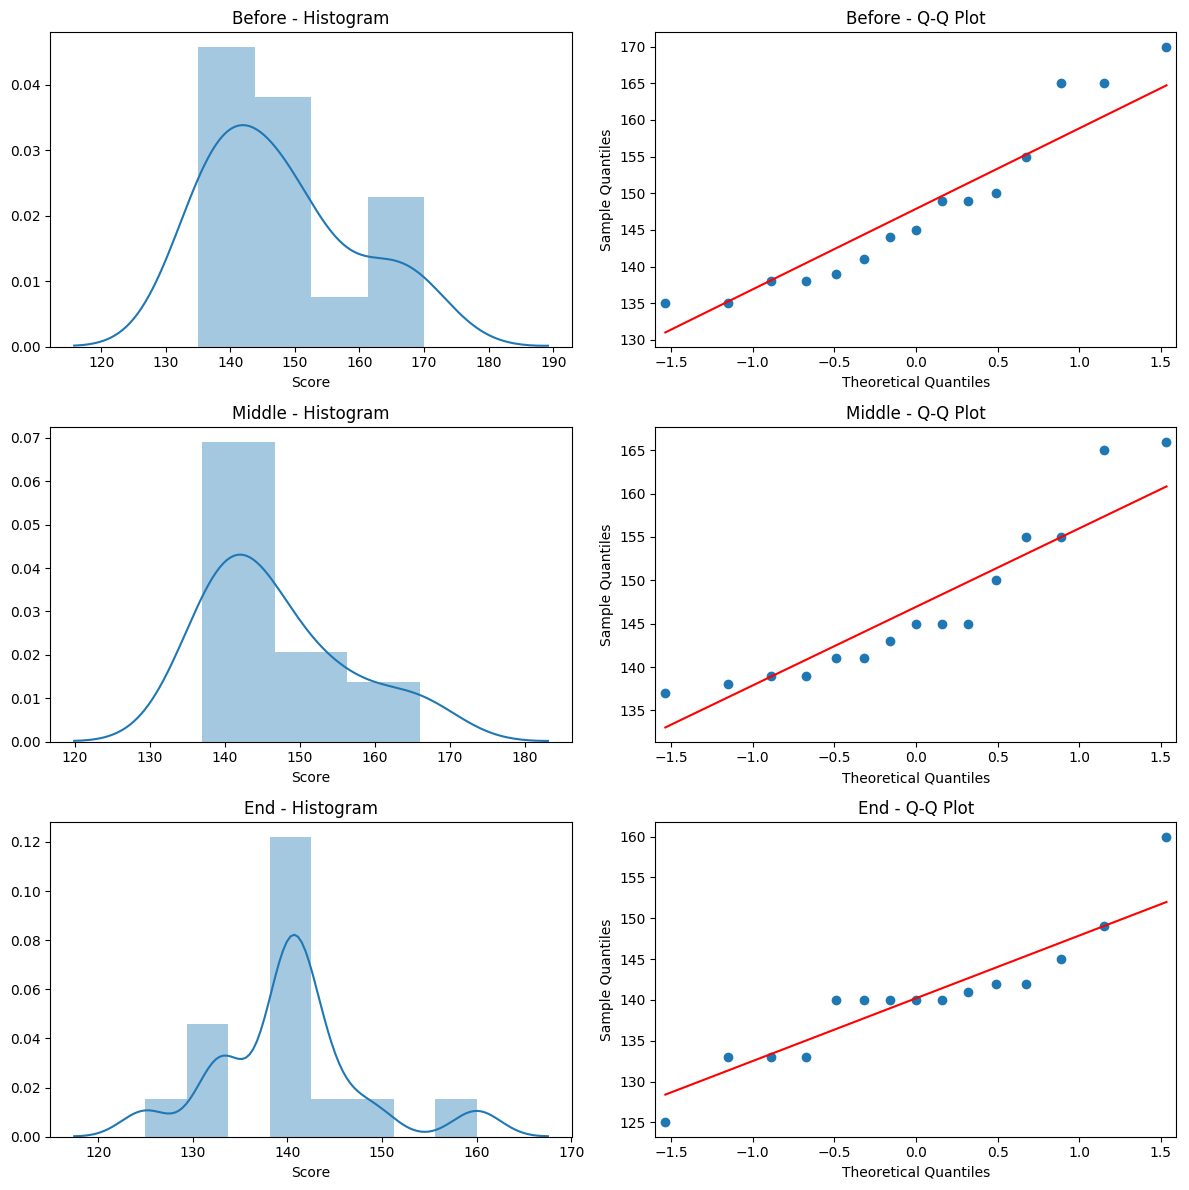

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, group in enumerate(df_long['Time'].unique()):
    data = df_long[df_long['Time'] == group]['Score']
    
    # Histogram
    sns.distplot(data, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{group} - Histogram')
    
    # QQ plot
    sm.qqplot(data, line='s', ax=axes[i, 1])
    axes[i, 1].set_title(f'{group} - Q-Q Plot')

plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import levene

group_A = df_long[df_long['Time'] == 'Before']['Score']
group_B = df_long[df_long['Time'] == 'Middle']['Score']
group_C = df_long[df_long['Time'] == 'End']['Score']

# Levene's test (mean 기준)
lev_stat, lev_p = levene(group_A, group_B, group_C)
print(f"\nLevene’s Test (Mean 기준): F = {lev_stat:.2f}, df = (2, {len(df)-3}), p = {lev_p:.3f}")

# Brown-Forsythe test (median 기준)
bf_stat, bf_p = levene(group_A, group_B, group_C, center='median')
print(f"Brown-Forsythe Test (Median 기준): F = {bf_stat:.2f}, df = (2, {len(df)-3}), p = {bf_p:.3f}")


Levene’s Test (Mean 기준): F = 1.28, df = (2, 12), p = 0.290
Brown-Forsythe Test (Median 기준): F = 1.28, df = (2, 12), p = 0.290


# Repeated Measures ANOVA (with η²)

In [24]:
# 3. Repeated Measures ANOVA 수행
anova = pg.rm_anova(dv='Score', within='Time', subject='Subject', data=df_long, detailed=True)

# 4. 결과 출력
anova.round(3)

,Source,SS,DF,MS,F,p-unc,np2,eps
0,Time,524.933,2,262.467,5.437,0.01,0.28,0.872
1,Error,1351.733,28,48.276,NaN,NaN,NaN,NaN


# 사후 검정 : Bonferroni Post-hoc-Tests

In [27]:
import pingouin as pg

# df_long은 반복측정용 long format
posthoc = pg.pairwise_ttests(dv='Score', within='Time', subject='Subject',
                             data=df_long, padjust='bonf')

posthoc

,Contrast,A,B,Paired,Parametric,T,dof,Tail,p-unc,p-corr,p-adjust,BF10,hedges
0,Time,Before,End,True,True,2.792094,14.0,two-sided,0.014403,0.043208,bonf,4.133,0.760179
1,Time,Before,Middle,True,True,0.334296,14.0,two-sided,0.743112,1.000000,bonf,0.276,0.087143
2,Time,End,Middle,True,True,-3.376866,14.0,two-sided,0.004516,0.013548,bonf,10.774,-0.753382


Before와 End그룹, End와  Middle 그룹에서 유의수준 0.05 에서 귀무가설을 기각하므로 통계적으로 유의한 차이가 있다고 말할 수 있다. 

**p-corr : Bonferroni 보정 후 p-value 을 보면 된다** 

# 반복 측정을 이용한 이원 분산 분석(two-way ANOVA)

<예시>
- 두 개의 요인(factor) 이 생깁니다:
	1.	치료 시점 (Before, Middle, End) – 반복 측정된 요인
	2.	치료 방법 (Therapy A, B, C) – 독립된 그룹

- 이처럼 요인이 **두 개**이고, 이 중 **하나가 반복 측정된 요인** -> 반복 측정이 포함된 이원분산분석(two-way repeated measures ANOVA) 을 사용

![Example](./One-factorial_vs_Two-factorial_ANOVA_with_repeated_measures.png)

![Example](./Example_Two-Factor_ANOVA_with_Measurement_Repetition.png)

1. 
- 귀무가설 : 시간별 평균 혈압은 차이가 없다
- 대립가설 : 시간별 중 적어도 하나에 평균 혈압 차이가 있다


2. 
- 귀무가설 : 치료법 간 평균 혈압은 차이가 없다
- 대립가설 : 치료법 중 적어도 하나에 평균 혈압에 차이가 있다
3. 
- 귀무가설 : 시간과 치료법 간 상호작용이 없다
- 대립가설 : 시간과 치료법 간 상호작용이 있다


In [1]:
import pandas as pd

data = {
    'Therapy': ['A'] * 5 + ['B'] * 5 + ['C'] * 5,
    'Before': [165, 155, 138, 150, 149, 135, 145, 170, 138, 144, 165, 139, 141, 149, 135],
    'Middle': [145, 139, 141, 145, 155, 138, 150, 166, 143, 145, 155, 165, 139, 141, 137],
    'End':    [140, 133, 140, 145, 149, 125, 142, 160, 140, 142, 133, 140, 141, 140, 133]
}

df = pd.DataFrame(data)
df['Subject'] = df.index + 1  # 반복측정은 필요함
df

,Therapy,Before,Middle,End,Subject
0,A,165,145,140,1
1,A,155,139,133,2
2,A,138,141,140,3
3,A,150,145,145,4
4,A,149,155,149,5
5,B,135,138,125,6
6,B,145,150,142,7
7,B,170,166,160,8
8,B,138,143,140,9
9,B,144,145,142,10


In [3]:
# 데이터 포맷을 long-form으로 변환
df_long = pd.melt(df, id_vars=['Therapy','Subject'], value_vars=['Before', 'Middle', 'End'],
                  var_name='Time', value_name='BloodPressure')

df_long

,Therapy,Subject,Time,BloodPressure
0,A,1,Before,165
1,A,2,Before,155
2,A,3,Before,138
3,A,4,Before,150
4,A,5,Before,149
5,B,6,Before,135
6,B,7,Before,145
7,B,8,Before,170
8,B,9,Before,138
9,B,10,Before,144


In [6]:
import pingouin as pg

# 구형성 검정 수행
sphericity = pg.sphericity(data=df_long, dv='BloodPressure', subject='Subject', within='Time')
print("=== Mauchly’s Test of Sphericity ===")
sphericity

=== Mauchly’s Test of Sphericity ===


SpherResults(spher=True, W=0.8533042981018578, chi2=2.0623077334263287, dof=2, pval=0.35659525969062694)

In [8]:
# 해석 : p_value 값이 0.356으로 유의수준 0.05 보다 크므로 귀무가설을 기각하지 못한다. 즉, 구형성이 통계적으로 유의하다고 말할 수 있다.

In [7]:
df_long

,Therapy,Subject,Time,BloodPressure
0,A,1,Before,165
1,A,2,Before,155
2,A,3,Before,138
3,A,4,Before,150
4,A,5,Before,149
5,B,6,Before,135
6,B,7,Before,145
7,B,8,Before,170
8,B,9,Before,138
9,B,10,Before,144


In [9]:
import scipy.stats as stats
import numpy as np
from statsmodels.stats.diagnostic import lilliefors

for group in df_long['Time'].unique():
    data = df_long[df_long['Time'] == group]['BloodPressure']
    
    print(f"\n=== {group} ===")
    
    # Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
    print(f"Kolmogorov-Smirnov: stat={ks_stat:.2f}, p={ks_p:.3f}")
    
    # Lilliefors (Kolmogorov-Smirnov 수정)
    lf_stat, lf_p = lilliefors(data)
    print(f"Lilliefors (K-S 수정): stat={lf_stat:.2f}, p={lf_p:.3f}")
    
    # Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(f"Shapiro-Wilk: stat={shapiro_stat:.2f}, p={shapiro_p:.3f}")


=== Before ===
Kolmogorov-Smirnov: stat=0.16, p=0.804
Lilliefors (K-S 수정): stat=0.16, p=0.392
Shapiro-Wilk: stat=0.90, p=0.084

=== Middle ===
Kolmogorov-Smirnov: stat=0.25, p=0.254
Lilliefors (K-S 수정): stat=0.25, p=0.015
Shapiro-Wilk: stat=0.86, p=0.023

=== End ===
Kolmogorov-Smirnov: stat=0.22, p=0.387
Lilliefors (K-S 수정): stat=0.22, p=0.043
Shapiro-Wilk: stat=0.91, p=0.122


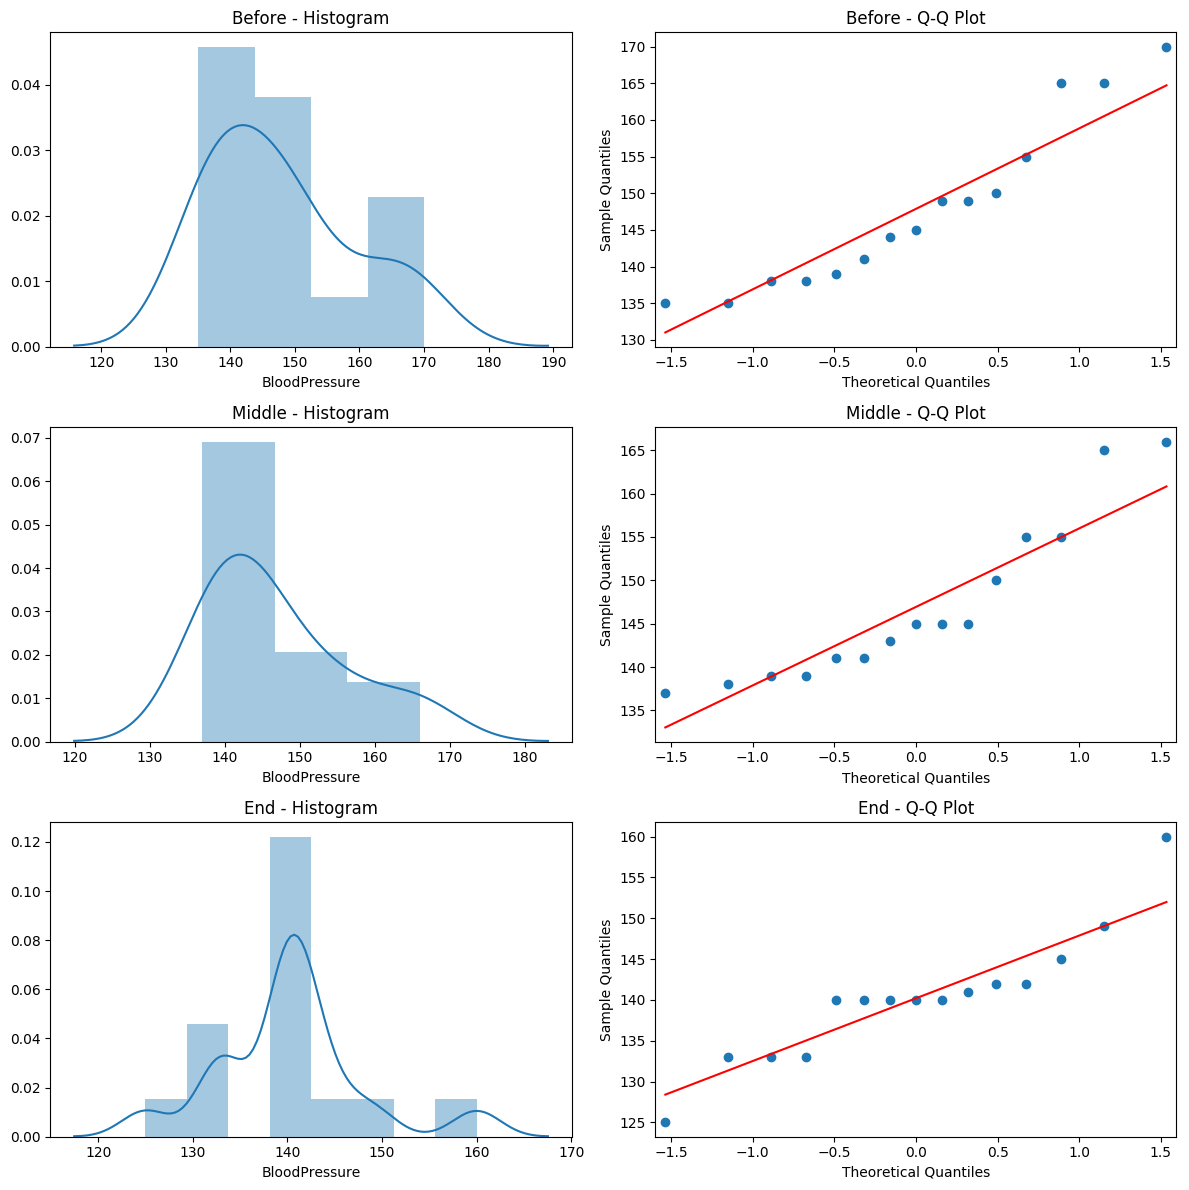

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, group in enumerate(df_long['Time'].unique()):
    data = df_long[df_long['Time'] == group]['BloodPressure']
    
    # Histogram
    sns.distplot(data, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{group} - Histogram')
    
    # QQ plot
    sm.qqplot(data, line='s', ax=axes[i, 1])
    axes[i, 1].set_title(f'{group} - Q-Q Plot')

plt.tight_layout()
plt.show()

In [13]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

model = mixedlm("BloodPressure ~ Time * Therapy", data=df_long, groups=df_long["Subject"])
result = model.fit()
print(result.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     BloodPressure
No. Observations:       45          Method:                 REML         
No. Groups:             15          Scale:                  50.7111      
Min. group size:        3           Log-Likelihood:         -137.5343    
Max. group size:        3           Converged:              Yes          
Mean group size:        3.0                                              
-------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------
Intercept                   151.400    4.560 33.202 0.000 142.463 160.337
Time[T.End]                 -10.000    4.504 -2.220 0.026 -18.827  -1.173
Time[T.Middle]               -6.400    4.504 -1.421 0.155 -15.227   2.427
Therapy[T.B]                 -5.000    6.449 -0.775 0.43

# 혼합모형 분산분석(Mixed-model ANOVA)이란?

- 집단 간 차이(Between-subjects)
- 반복측정 요인(Within-subjects)


  두 가지를 동시에 분석할 수 있는 고급 통계기법

    - A, B, C라는 **치료 그룹(집단 간 요인)** 이 있고
	- 각각의 그룹에서 **시점(Before, Middle, End)** 에 따른 **혈압 변화(반복측정 요인)** 를 측정했다면 → 혼합모형 ANOVA가 적절

In [ ]:
import pingouin as pg

# Mixed ANOVA (Time: within-subject, Therapy: between-subject) 

######## 하지만 해당 버전에서는 불가능 ################
aov = pg.mixed_anova(data=df_long,
                     dv='BloodPressure',
                     within='Time',
                     between='Therapy',
                     subject='Subject',
                     correction=True)

print(aov)

In [ ]:
#         Source          SS  DF1  DF2          MS         F     p-unc  \
# 0      Therapy   49.600000    2   12   24.800000  0.117827  0.889865   
# 1         Time  524.933333    2   24  262.466667  5.175723  0.013527   
# 2  Interaction  134.666667    4   24   33.666667  0.663891  0.623181   

#    p-GG-corr       np2       eps sphericity   W-spher   p-spher  
# 0        NaN  0.019260       NaN        NaN       NaN       NaN  
# 1   0.013883  0.301339  0.872071       True  0.853304  0.356595  
# 2        NaN  0.099625       NaN        NaN       NaN       NaN  

# 치료군 간 차이는 없음 (Therapy: p = 0.89)
# 시간의 흐름에 따른 혈압 변화는 유의미함 (Time: p = 0.013)
# 그러나 치료군 × 시간 간 상호작용 효과는 없음 (Interaction: p = 0.623)

In [15]:
# 반복측정 일원배치 분산분석 수행
rm_anova = pg.rm_anova(dv='BloodPressure',
                       within='Time',
                       subject='Subject',
                       data=df_long,
                       correction=True,   # 구형성 위반 시 보정
                       detailed=True)

# 결과 출력
print(rm_anova)

  Source           SS  DF          MS         F     p-unc  p-GG-corr  \
0   Time   524.933333   2  262.466667  5.436773  0.010117   0.013883   
1  Error  1351.733333  28   48.276190       NaN       NaN        NaN   

        np2       eps sphericity   W-spher   p-spher  
0  0.279716  0.872071       True  0.853304  0.356595  
1       NaN       NaN        NaN       NaN       NaN  


- 해석 : p_value 가 0.010117이므로 유의수준 0.05에서 귀무가설을 기각하여 통계적으로 유의미한 차이가 있다고 판단한다.
- η² = 0.28은 전체 분산 중 28%가 처치 요인에 의해 설명된다는 의미이며 0.14 이상 = 큰 효과 (large)로 판단하므로 즉, 매우 큰 효과 크기로 해석할 수 있다.
  
- **세 시점(Before, Middle, End) 사이에 유의미한 차이가 있으며, 이 차이는 실질적으로도 중요한 크기를 갖는다는 것을 의미한다.**

In [19]:
# 반복측정 요인(Time)에 대한 사후검정
posthoc_time = pg.pairwise_ttests(data=df_long,
                                  dv='BloodPressure',
                                  within='Time',
                                  subject='Subject',
                                  padjust='bonf',  # Bonferroni 보정
                                  effsize='cohen')  # 효과크기 포함

posthoc_time

,Contrast,A,B,Paired,Parametric,T,dof,Tail,p-unc,p-corr,p-adjust,BF10,cohen
0,Time,Before,End,True,True,2.792094,14.0,two-sided,0.014403,0.043208,bonf,4.133,0.781295
1,Time,Before,Middle,True,True,0.334296,14.0,two-sided,0.743112,1.000000,bonf,0.276,0.089564
2,Time,End,Middle,True,True,-3.376866,14.0,two-sided,0.004516,0.013548,bonf,10.774,-0.774309


1. Before vs. Middle
    - p_value : 1.00 
    - 유의수준 0.05하에서 유의미한 차이가 없다. 치료 전과 중간 단계의 혈압 차이는 통계적으로 유의하지 않다.
    
2. Before vs. End
    - p_value = 0.043
    - 유의수준 0.05하에서 유의미한 차이가 있다. 치료 전과 치료 후의 혈압 차이에는 유의미한 차이가 있다.   
    
3. Middle vs. End
    - p_value = 0.004
    - 유의수준 0.05하에서 유의미한 차이가 있다. 치료 중과 치료 후의 혈압 차이에는 유의미한 차이가 있다.